In [336]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/SP500.csv
/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/DJUA.csv
/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/DJTA.csv
/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/DJCA.csv
/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/DJIA.csv


# **An analysis of the Dow Jones Price 2016-2026**
Saving a copy of the csv file as a DataFrame and inspecting it.

In [337]:
df = pd.read_csv('/kaggle/input/datasets/joebeachcapital/dow-jones-and-s-and-p500-indices-daily-update/DJIA.csv').copy()
df

,observation_date,DJIA
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


# **Cleaning of the initial DataFrame**

Changing the column names of "*observation_date*" to "*Date*" and "*DJIA*" to "*Price*".

In [338]:
df.columns = ['Date', 'Price']
df

,Date,Price
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


Removing rows that have the same values in all columns.

In [339]:
df = df.drop_duplicates()
df

,Date,Price
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


Filtering for values that have missing data (price or date), which were 94 rows in total.

In [340]:
df1 = df[df.isnull().any(axis=1)]
df1

,Date,Price
40,2016-05-30,NaN
65,2016-07-04,NaN
110,2016-09-05,NaN
168,2016-11-24,NaN
190,2016-12-26,NaN
...,...,...
2518,2025-11-27,NaN
2538,2025-12-25,NaN
2543,2026-01-01,NaN
2555,2026-01-19,NaN


Deleting rows with missing values.

In [341]:
df = df.dropna()
df

,Date,Price
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


Checking for rows with missing values.

In [342]:
df1 = df[df.isnull().any(axis=1)]
df1

,Date,Price


Changing the Price column values to numeric.

In [343]:
df = df.copy()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df

,Date,Price
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


Checking if there are values that couldn't be converted.

In [344]:
df1 = df[df.isnull().any(axis=1)]
df1

,Date,Price


Changing Date column values to datetime type.

In [345]:
df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df

,Date,Price
0,2016-04-04,17737.00
1,2016-04-05,17603.32
2,2016-04-06,17716.05
3,2016-04-07,17541.96
4,2016-04-08,17576.96
...,...,...
2604,2026-03-27,45166.64
2605,2026-03-30,45216.14
2606,2026-03-31,46341.51
2607,2026-04-01,46565.74


Displaying all non datetime types.

In [346]:
df1 = df[df.isnull().any(axis=1)]
df1

,Date,Price


Checking for correct datatypes (datetime and float).

In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2515 entries, 0 to 2608
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2515 non-null   datetime64[ns]
 1   Price   2515 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 58.9 KB


# **Adding of columns**

Adding a column that only uses the Month and Year of the Date column.

In [348]:
df = df.copy()
df['Date Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
df

,Date,Price,Date Month
0,2016-04-04,17737.00,2016-04
1,2016-04-05,17603.32,2016-04
2,2016-04-06,17716.05,2016-04
3,2016-04-07,17541.96,2016-04
4,2016-04-08,17576.96,2016-04
...,...,...,...
2604,2026-03-27,45166.64,2026-03
2605,2026-03-30,45216.14,2026-03
2606,2026-03-31,46341.51,2026-03
2607,2026-04-01,46565.74,2026-04


Adding a column that only uses the Year of the Date column.

In [349]:
df = df.copy()
df['Date Year'] = pd.to_datetime(df['Date']).dt.to_period('Y')
df

,Date,Price,Date Month,Date Year
0,2016-04-04,17737.00,2016-04,2016
1,2016-04-05,17603.32,2016-04,2016
2,2016-04-06,17716.05,2016-04,2016
3,2016-04-07,17541.96,2016-04,2016
4,2016-04-08,17576.96,2016-04,2016
...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026
2605,2026-03-30,45216.14,2026-03,2026
2606,2026-03-31,46341.51,2026-03,2026
2607,2026-04-01,46565.74,2026-04,2026


Creating average prices for the Date Month column and adding them to a new column.

In [350]:
df = df.copy()
df['Month Price'] = df.groupby('Date Month')['Price'].transform('mean')
df

,Date,Price,Date Month,Date Year,Month Price
0,2016-04-04,17737.00,2016-04,2016,17846.946500
1,2016-04-05,17603.32,2016-04,2016,17846.946500
2,2016-04-06,17716.05,2016-04,2016,17846.946500
3,2016-04-07,17541.96,2016-04,2016,17846.946500
4,2016-04-08,17576.96,2016-04,2016,17846.946500
...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273
2605,2026-03-30,45216.14,2026-03,2026,46859.672273
2606,2026-03-31,46341.51,2026-03,2026,46859.672273
2607,2026-04-01,46565.74,2026-04,2026,46535.205000


Creating average prices for the Date Year column and adding them to a new column.

In [351]:
df = df.copy()
df['Year Price'] = df.groupby('Date Year')['Price'].transform('mean')
df


,Date,Price,Date Month,Date Year,Month Price,Year Price
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474
...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302


# **Visual analysis and specifing the downturns of the Dow Jones**

Creating a line graph visualisation of the three Price types (Daily, Monthly and Yearly).

,Date,Price,Date Month,Date Year,Month Price,Year Price
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474
...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302


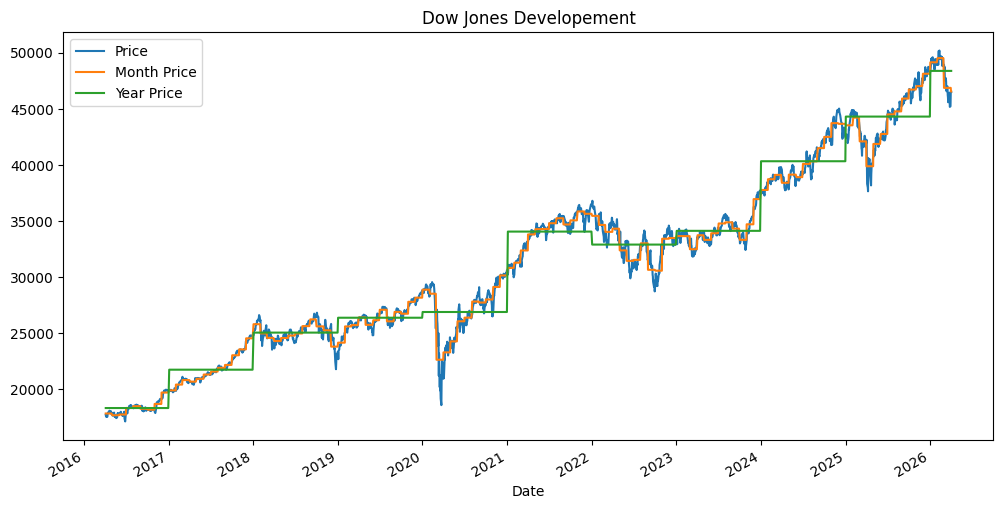

In [352]:
df.plot(x='Date', y=['Price', 'Month Price', 'Year Price'], figsize=(12,6), title='Dow Jones Developement')
df

**Findings**
* On a yearly base the dow jones only lost points during 2022, which indicates a bull market during the past decade
* The monthly price tracks the daily similarly with the exception of strong volatility

Adding a change in daily percentage, to better identifie returns.

In [353]:
df.copy()
df['Percentage Change'] = df['Price'].pct_change() * 100
df


,Date,Price,Date Month,Date Year,Month Price,Year Price,Percentage Change
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474,NaN
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474,-0.753679
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474,0.640391
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474,-0.982668
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474,0.199522
...,...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302,-1.726432
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302,0.109594
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302,2.488868
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302,0.483864


Inspecting the daily percentage change of the Dow Jones.

<Axes: title={'center': 'Daily Percentage Change'}, xlabel='Date'>

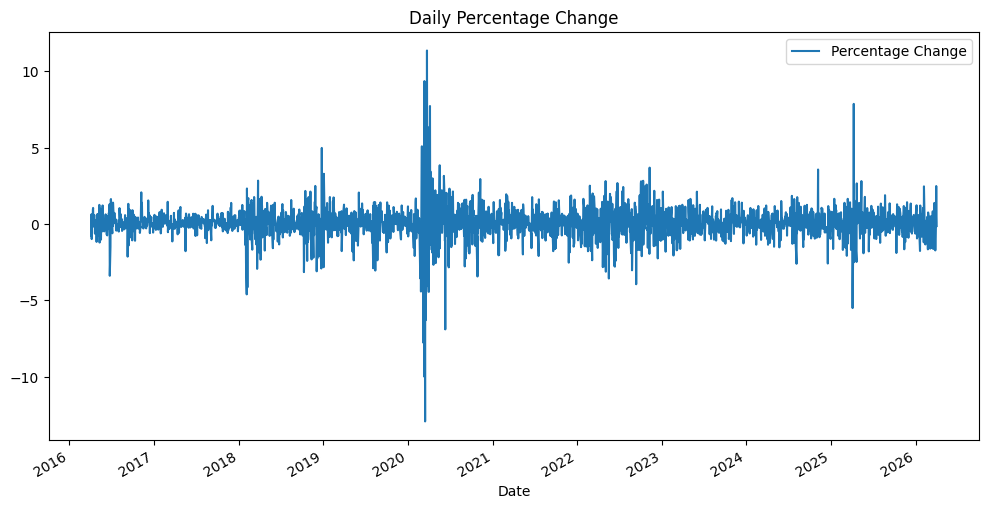

In [354]:
df.plot(x='Date', y='Percentage Change', figsize=(12,6), title='Daily Percentage Change')

**Findings**
* Strong volatility
* Visually their could be 2 downturns at the beginning of 2020, the midle of 2020 and the beginning of 2025

Adding monthly percentage change.

In [355]:
df['Monthly Percentage Change'] = df['Month Price'].pct_change() * 100
df

,Date,Price,Date Month,Date Year,Month Price,Year Price,Percentage Change,Monthly Percentage Change
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474,NaN,NaN
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474,-0.753679,0.000000
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474,0.640391,0.000000
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474,-0.982668,0.000000
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474,0.199522,0.000000
...,...,...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302,-1.726432,0.000000
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302,0.109594,0.000000
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302,2.488868,0.000000
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302,0.483864,-0.692423


Inspecting monthly percentage change of the Dow Jones.

<Axes: title={'center': 'Monthly Percentage Change'}, xlabel='Date Month'>

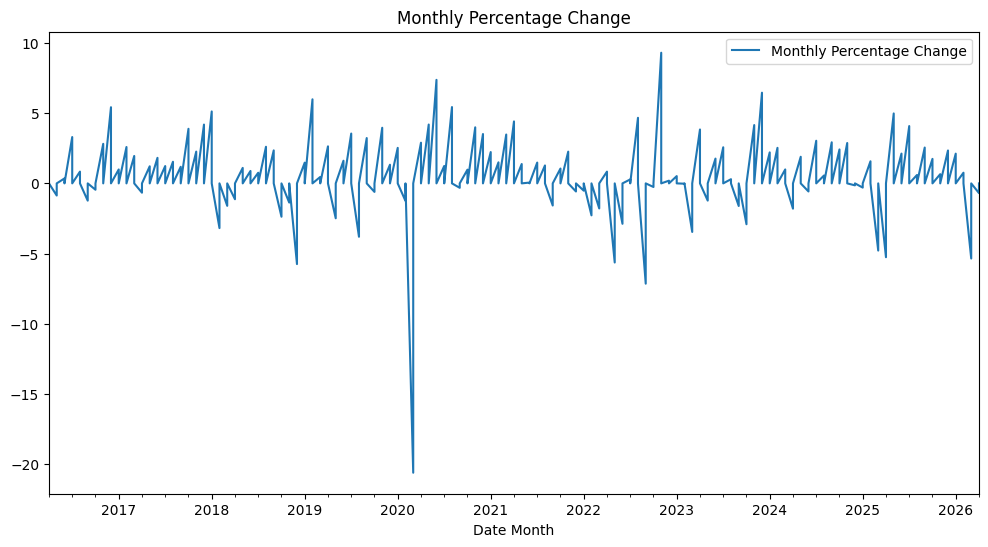

In [356]:
df.plot(x='Date Month', y='Monthly Percentage Change', figsize=(12,6), title='Monthly Percentage Change')

Adding yearly percentage change.

In [357]:
df['Yearly Percentage Change'] = df['Year Price'].pct_change() * 100
df

,Date,Price,Date Month,Date Year,Month Price,Year Price,Percentage Change,Monthly Percentage Change,Yearly Percentage Change
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474,NaN,NaN,NaN
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474,-0.753679,0.000000,0.0
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474,0.640391,0.000000,0.0
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474,-0.982668,0.000000,0.0
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474,0.199522,0.000000,0.0
...,...,...,...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302,-1.726432,0.000000,0.0
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302,0.109594,0.000000,0.0
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302,2.488868,0.000000,0.0
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302,0.483864,-0.692423,0.0


Inspecting yearly percentage change of the Dow Jones.

<Axes: title={'center': 'Yearly Percentage Change'}, xlabel='Date Year'>

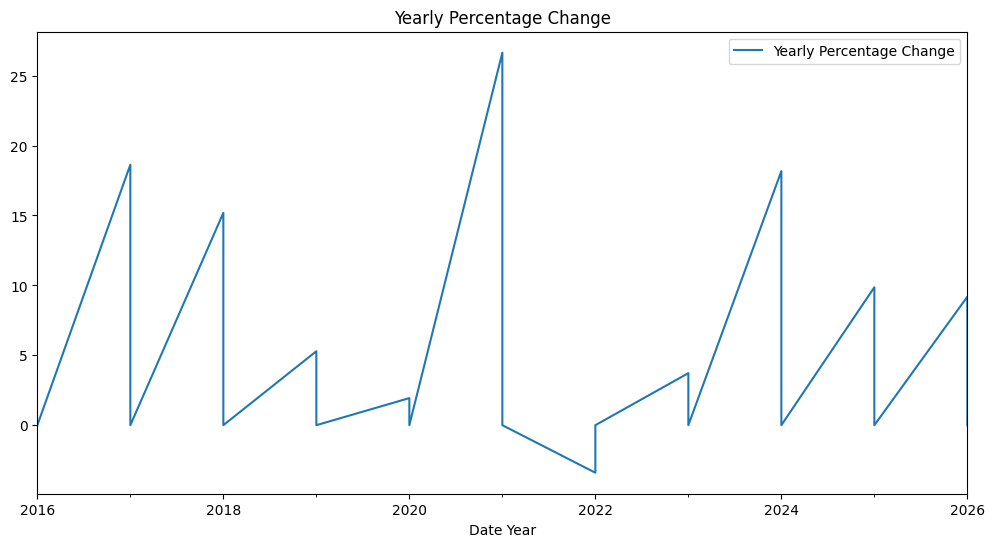

In [358]:
df.plot(x='Date Year', y='Yearly Percentage Change', figsize=(12,6), title='Yearly Percentage Change')

**Findings**
* We will use the monthly data, due to less *noise*, compared to the daily change, and it is still able to show downturns, other than the yearly.

Adding different down turn types based on the negative performance of the monthly percentage return of the Dow Jones.

In [359]:
df.copy()
conditions = [
    (df['Monthly Percentage Change'] <= -20), # Minuszeichen nicht vergessen bei Downturns!
    (df['Monthly Percentage Change'] <= -10) & (df['Monthly Percentage Change'] > -20),
    (df['Monthly Percentage Change'] <= -5) & (df['Monthly Percentage Change'] > -10)
]

values = ['Crash', 'Correction', 'Dip']

df['downturn type'] = np.select(conditions, values, default='Normal')
df

,Date,Price,Date Month,Date Year,Month Price,Year Price,Percentage Change,Monthly Percentage Change,Yearly Percentage Change,downturn type
0,2016-04-04,17737.00,2016-04,2016,17846.946500,18333.649474,NaN,NaN,NaN,Normal
1,2016-04-05,17603.32,2016-04,2016,17846.946500,18333.649474,-0.753679,0.000000,0.0,Normal
2,2016-04-06,17716.05,2016-04,2016,17846.946500,18333.649474,0.640391,0.000000,0.0,Normal
3,2016-04-07,17541.96,2016-04,2016,17846.946500,18333.649474,-0.982668,0.000000,0.0,Normal
4,2016-04-08,17576.96,2016-04,2016,17846.946500,18333.649474,0.199522,0.000000,0.0,Normal
...,...,...,...,...,...,...,...,...,...,...
2604,2026-03-27,45166.64,2026-03,2026,46859.672273,48372.637302,-1.726432,0.000000,0.0,Normal
2605,2026-03-30,45216.14,2026-03,2026,46859.672273,48372.637302,0.109594,0.000000,0.0,Normal
2606,2026-03-31,46341.51,2026-03,2026,46859.672273,48372.637302,2.488868,0.000000,0.0,Normal
2607,2026-04-01,46565.74,2026-04,2026,46535.205000,48372.637302,0.483864,-0.692423,0.0,Normal


Visualising the Crash, Correction or Dips of the Dow Jones, on a monthly base.

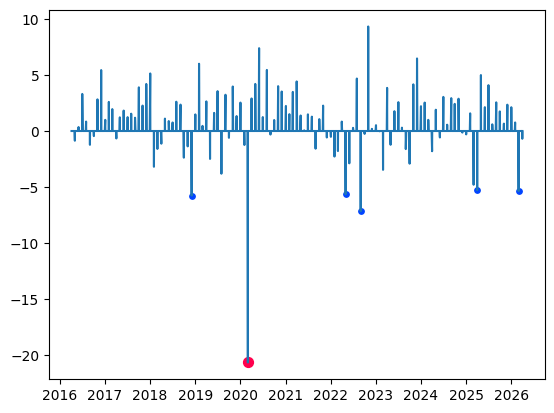

In [360]:
import matplotlib.pyplot as plt

crashes = df[df['downturn type'] == 'Crash']
corrections = df[df['downturn type'] == 'Correction']
dips = df[df['downturn type'] == 'Dip']

# Jetzt plotten wir sie einzeln mit eigenen Farben
plt.scatter(crashes['Date'], crashes['Monthly Percentage Change'], color='#FF004D', label='Crash', s=50)
plt.scatter(corrections['Date'], corrections['Monthly Percentage Change'], color='#FF00F7', label='Correction', s=30)
plt.scatter(dips['Date'], dips['Monthly Percentage Change'], color='#0044FF', label='Dip', s=15)

plt.plot(df['Date'], df['Monthly Percentage Change'])
plt.show()

**Findings**
* The previous assumption of only 3 downturns was wrong
* There are 5 dips and 1 crash

Inspecting the 6 downturns.

In [363]:
categories = ['Crash', 'Correction', 'Dip']
mask = df['downturn type'].isin(categories)
downturns = df[mask]
print(downturns)

           Date     Price Date Month Date Year   Month Price    Year Price  \
695  2018-12-03  25826.43    2018-12      2018  23805.545263  25053.949960   
1020 2020-03-02  26703.32    2020-03      2020  22637.420909  26890.673597   
1585 2022-05-02  33061.50    2022-05      2022  32379.462857  32897.345179   
1673 2022-09-01  31656.42    2022-09      2022  30649.559524  32897.345179   
2346 2025-04-01  41989.96    2025-04      2025  39876.327619  44301.537360   
2585 2026-03-02  48904.78    2026-03      2026  46859.672273  48372.637302   

      Percentage Change  Monthly Percentage Change  Yearly Percentage Change  \
695            1.127593                  -5.752994                       0.0   
1020           5.092454                 -20.625407                       0.0   
1585           0.255601                  -5.640471                       0.0   
1673           0.463307                  -7.149459                       0.0   
2346          -0.028094                  -5.264170   

Displaying the Downturns on a chart of monthly price developement of the Dow Jones and using grey arrows for Dips and Black for Crashes. The Downturns have been labeled with a possible cause.

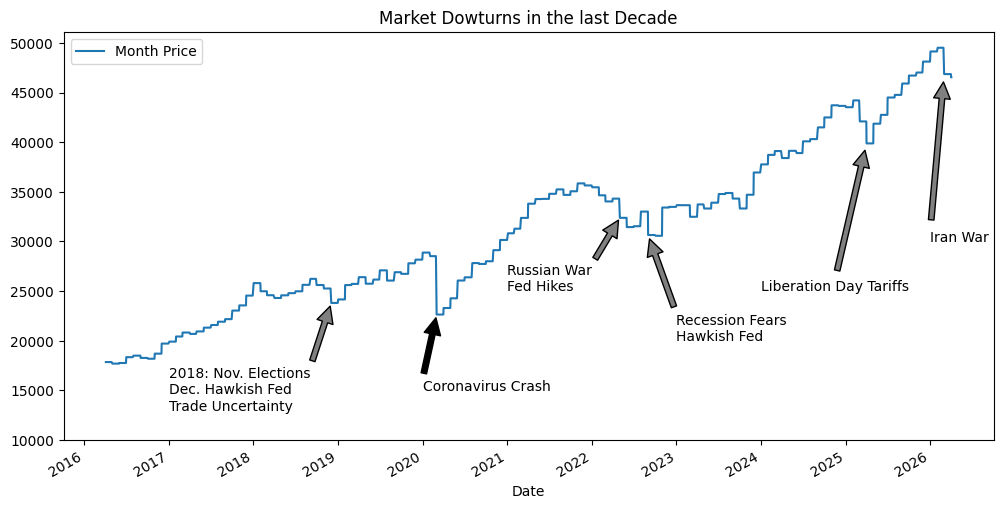

In [365]:
df.plot(x='Date', y='Month Price', figsize=(12,6), title='Market Dowturns in the last Decade')
plt.annotate('2018: Nov. Elections\nDec. Hawkish Fed\nTrade Uncertainty', 
             xy=('2018-12-03', 23805.545263), xytext=('2017', 13000),
            arrowprops=dict(facecolor='grey', shrink=0.05))

plt.annotate('Coronavirus Crash', xy=('2020-03-02', 22637.420909), xytext=('2020', 15000),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate('Russian War\nFed Hikes', xy=('2022-05-02', 32379.462857), xytext=('2021', 25000),
            arrowprops=dict(facecolor='grey', shrink=0.05))

plt.annotate('Recession Fears\nHawkish Fed', xy=('2022-09-01', 30649.559524), xytext=('2023', 20000),
            arrowprops=dict(facecolor='grey', shrink=0.05))

plt.annotate('Liberation Day Tariffs', xy=('2025-04-01', 39876.327619), xytext=('2024', 25000),
            arrowprops=dict(facecolor='grey', shrink=0.05))

plt.annotate('Iran War', xy=('2026-03-02', 46859.672273), xytext=('2026', 30000),
            arrowprops=dict(facecolor='grey', shrink=0.05))

plt.ylim(bottom=10000)
plt.show()

# **Final outcome**
* The dow jones had 6 downturns with a loss of more than 5% compared to the previous month
* The dow jones had 5 dips
* The dow jones had 1 crash
* The only time the downturn didn't recover was during the 2022 dips, which could be the combination of a bad economy(recession) and a hawkish fed

### Sources

* **[1] Dec 2018 (Fed, Elections & Tariff uncertainty):** [Schroders: Monthly markets review – November 2018](https://www.schroders.com/en/global/individual/insights/monthly-markets-review---november-2018/), [The Guardian: Federal Reserve raises interest rates despite pressure from Trump](https://www.theguardian.com/business/2018/dec/19/federal-reserve-interest-rates-raised-trump) & [The Guardian: Trade war truce: markets jump as Trump says China will halt new car tariffs](https://www.theguardian.com/world/2018/dec/03/trade-war-china-trump-markets-jump-car-tariffs)

* **[2] March 2020 (Coronavirus Crash):** [Forbes: The Coronavirus Crash Of 2020 And The Investing Lesson It Taught Us](https://www.forbes.com/sites/lizfrazierpeck/2021/02/11/the-coronavirus-crash-of-2020-and-the-investing-lesson-it-taught-us/)

* **[3] May 2022 (Russian War & Fed Hikes):** [Reuters: Global markets 2022 – A year of shocks](https://www.reuters.com/markets/global-markets-wrapup-1-pix-2022-12-22/)

* **[4] Sept 2022 (Fed Interest Rate Hikes & Recession Fears):** [CNBC: Fed raises rates by another three-quarters of a percentage point](https://www.cnbc.com/2022/09/21/fed-rate-hike-september-2022-.html) & [Reuters: Futures steady after Fed-driven selloff](https://www.reuters.com/markets/europe/futures-steady-after-fed-driven-selloff-2022-09-22/)

* **[5] April 2025 (Liberation Day & Market Corrections):** [Yahoo Finance: The S&P 500 did something in April it hasn't done in over a year](https://finance.yahoo.com/news/p-500-did-something-april-070600927.html)

* **[6] March 2026 (Geopolitical Tension & Iran Conflict):** [U.S. Bank: Is a market correction coming? Market volatility and geopolitical news](https://www.usbank.com/investing/financial-perspectives/market-news/is-a-market-correction-coming.html)